# Домашнее задание 08-09

### Петров Александр ИКБО-40-24

**Выбранный датасет - CIFAR10.**

## 0. Импортированные модули, вспомогательные функции и воспроизводимость

**Импортированные модули**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision.datasets.cifar import CIFAR10
import torchvision.transforms.v2 as v2

import random
from pathlib import Path
import os
import json
import csv

# Все пути
ARTIFACTS_PATH = Path("./artifacts")
FIGURES_PATH = ARTIFACTS_PATH / "figures"
ARTIFACTS_PATH.mkdir(exist_ok=True)
FIGURES_PATH.mkdir(exist_ok=True)

DATA_PATH = Path("./data")
CIFAR10_DOWNLOAD_PATH = DATA_PATH / "downloads"

CIFAR10_TRAIN_DOWNLOAD_PATH = CIFAR10_DOWNLOAD_PATH / Path("./train/")
CIFAR10_TEST_DOWNLOAD_PATH = CIFAR10_DOWNLOAD_PATH / Path("./test/")

**Вспомогательные функции**

In [2]:
def show_ds_sample_images(
    loader: DataLoader,
    n_samples: int = 5
) -> None:
    """
    Выводит n_samples (по умолчанию 5) изображений в ряд из выборки loader
    """
    # Больше 10 плохо помещается на экран
    if n_samples > 10:
        raise ValueError("Слишком много изображений (требуется не больше 10)")
    
    # Берем изображения из 1 батча
    images, labels = next(iter(loader))
    
    # n_samples случайных индексов в батче
    indices = np.random.choice(len(images), n_samples, replace=False)
    
    fig, axes = plt.subplots(1, n_samples, figsize=(12, 5))
    
    # Параметры, используемые для нормализации
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])

    for i, idx in enumerate(indices):
        # Из (C, H, W) в (H, W, C), так как Matplotlib выводит изображения именно так
        img = images[idx].numpy().transpose(1, 2, 0)    
            
        # Денормализация для корректного отображения
        img = img * std + mean
        img = np.clip(img, 0, 1)  # обрезаем лишнее, чтобы не получать предупреждения matplotlib
        
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {labels[idx].item()}")
        axes[i].axis("off")
    
    plt.show()


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Реализация метрики Accuracy для классификации
    """
    # logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", filename: Path = Path("val_acc_curves.png")) -> None:
    """
    Рисует 2 графика:
      - loss: динамика изменения функции потерь для train и val выборок
      - accuracy: динамика изменения метрики accuracy для train и val выборок
    
    history ожидается вида:
    {
        "train_loss": [...], "val_loss":, [...],
        "train_acc": [...]. "val_acc": [...]
    }
    """
    # Рисуем по эпохам
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # loss-график
    axs[0].plot(epochs, history["train_loss"], label="train_loss")
    axs[0].plot(epochs, history["val_loss"], label="val_loss")
    axs[0].set_title(f"{title} - Loss")
    axs[0].legend()
    axs[0].grid(True)

    # accuracy-график
    axs[1].plot(epochs, history["train_acc"], label="train_acc")
    axs[1].plot(epochs, history["val_acc"], label="val_acc")
    axs[1].set_title(f"{title} - Accuracy")
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    
    # Сохранение, если указан путь
    if filename is not None:
        plt.savefig(filename)
        print(f"Plot saved to: {filename}")

    plt.show()

**Воспроизводимость**

In [3]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42

set_seed(SEED)

**Устройство**

In [4]:
def get_device() -> torch.device:
    # CUDA-устройство
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Ускорение для маковских ARM-чипов
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()
print("Device:", device)

Device: mps


## 1. Данные

Выбран CIFAR10. Установим его в директорию `./data/`.

In [5]:
# Трансформация данных
transform = v2.Compose(
    [
        v2.ToImage(),  # в картинку
        v2.ToDtype(dtype=torch.float32, scale=True),  # обязательно масштабируем и указываем тип
        v2.Normalize(  # нормализуем (хорошие значения для MLP)
            mean=[0.4914, 0.4822, 0.4465], 
            std=[0.2023, 0.1994, 0.2010]
        )
    ]
)

In [6]:
train_full_cifar_10 = CIFAR10(
    root=CIFAR10_TRAIN_DOWNLOAD_PATH,
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:23<00:00, 7.37MB/s] 


In [7]:
test_cifar_10 = CIFAR10(
    root=CIFAR10_TEST_DOWNLOAD_PATH,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:21<00:00, 7.90MB/s] 


Взглянем на классы в датасете, а также на размеры выборок.

In [8]:
print("Classes:\n", train_full_cifar_10.classes)

print("\nTrain + Val:", len(train_full_cifar_10))
print("Test:", len(test_cifar_10))

Classes:
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Train + Val: 50000
Test: 10000


In [9]:
# Динамический размер батча - для GPU будем использовать батчи побольше
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter Notebook проблема с воркерами, поэтому делаем проверку
NUM_WORKERS = 0 if os.name == "nt" else 2

# Разбиваем данные на train и val
gen = torch.Generator().manual_seed(SEED)
train_cifar_10, val_cifar_10 = random_split(
    train_full_cifar_10,
    [0.85, 0.15],
    generator=gen
)

print(len(train_cifar_10))
print(len(val_cifar_10))

# Создаем загрузчики для выборок
train_loader = DataLoader(
    train_cifar_10,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_cifar_10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_cifar_10,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

train_loader

42500
7500


In [10]:
# Sanity check
X_batch, y_batch = next(iter(train_loader))
print("X batch:", X_batch.shape, X_batch.dtype)
print("y batch:", y_batch.shape, y_batch.dtype)
print("Min X batch,", X_batch.min())
print("Max X batch:", X_batch.max())

X batch: torch.Size([64, 3, 32, 32]) torch.float32
y batch: torch.Size([64]) torch.int64
Min X batch, tensor(-2.4291)
Max X batch: tensor(2.7537)


Наконец, посмотрим на данные.

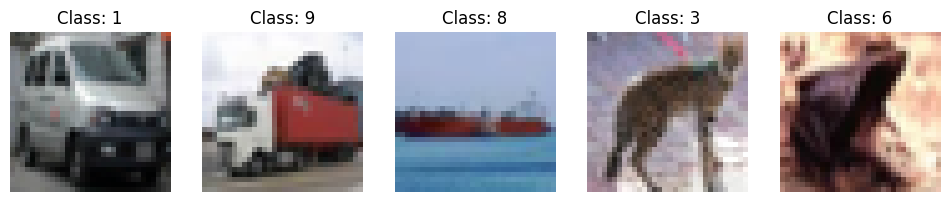

In [11]:
show_ds_sample_images(train_loader)

## 2. Модель MLP

Для начала, создадим пользовательский класс.

In [12]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 3 * 32 * 32,     # RGB изображения 32 на 32
        hidden_dims: tuple = (512, 256),  # скрытые слои
        num_classes: int = 10,            # выходные классы
        activation: str = "relu",         # базовая функция активации
        dropout_p: float = 0.0,           # Dropout
        use_batchnorm: bool = False,      # нормализация батчей
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        # Разворачиваем входное изображение в одномерный вектор
        layers: list[nn.Module] = [nn.Flatten()]

        # Ручное добавление слоев
        prev = input_dim
        for h in hidden_dims:
            # Скрытый слой
            layers.append(nn.Linear(prev, h))
            # BatchNormalization
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            # Функция активации
            layers.append(act_layer())
            # Dropout
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        # Выходной слой
        layers.append(nn.Linear(prev, num_classes))
        
        # Строим сеть из всех слоев
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(X_batch.to(device))
print("logits:", out.shape)  # должно быть (BATCH_SIZE, num_classes)

logits: torch.Size([64, 10])


Далее необходима будет возможность **ранней остановки**, реализуем соответствующий класс.

In [13]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience    # сколько эпох ждать улучшения, прежде чем остановить обучение
        self.min_delta = min_delta  # минимальный порог изменения метрики, который считается улучшением
        self.best_score = None
        self.best_state = None
        self.counter = 0
    
    # Обновляет состояние при каждой проверке
    def step(self, score: float, model: nn.Module) -> bool:
        # Инициализация при первом запуске
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        # Если метрика выросла (с учетом порога min_delta)
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        # Если улучшения нет, увеличиваем счетчик
        self.counter += 1
        # True, если нужно остановиться
        return self.counter >= self.patience

    # Сохраняет в модель лучшие веса
    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


Создадим цикл обучения.

In [14]:
def train_one_epoch(
    model,       # модель
    loader,      # датасет
    optimizer,   # оптимизатор
    criterion,   # функция ошибки
    device       # устройство
):
    # ! ВАЖНО: включаем режим обучения
    model.train()
    
    total_loss = 0.0
    total_accuracy = 0.0
    n_batches = 0
    
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        logits = model(X)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_accuracy += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_accuracy / n_batches


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):
    # ! Здесь также важно включить eval-режим
    model.eval()
    
    total_loss = 0.0
    total_accuracy = 0.0
    n_batches = 0
    
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        
        logits = model(X)
        loss = criterion(logits, y)
        
        total_loss += loss.item()
        total_accuracy += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_accuracy / n_batches


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

## 3. Регуляризация и переобучение (Часть А)

Мы проведем 4 эксперимента (E1 - E4):
  1. **E1 (base)**: 2-3 скрытых слоя MLP, без Dropout и BatchNorm.
  2. **E2 (Dropout)**: как E1, но с Dropout (p=0.2).
  3. **E3 (BatchNorm)**: как E1, но с BatchNorm.
  4. **E4 (EarlyStopping)**: комбинаци из E2 и E3; обучается с EarlyStopping.

Создадим общую функцию для экспериментов.

In [15]:
# Для хранения результатов
all_runs = []

def run_experiment(
    exp_id,              # ID эксперимента
    model_config,        # конфигурация модели
    opt_config,          # конфигурация оптимизатора
    epochs,              # кол-во эпох обучения
    early_stopping=None  # ранняя остановка
):
    # Для чистоты сбросим зерно в начале эксперимента
    set_seed(SEED)
    
    model = MLP(**model_config).to(device)
    
    # Выбор оптимизатора
    if opt_config["type"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0)
        )
    elif opt_config["type"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0),
            momentum=opt_config.get("momentum", 0)
        )
    else:
        raise ValueError(f"Correct use is \"Adam\" or \"SGD\" optimizer, got {opt_config["type"]}")
    
    # Функция ошибки
    criterion = nn.CrossEntropyLoss()
    
    # История обучения
    history = fit(
        model,
        train_loader, val_loader,
        optimizer, criterion, device,
        epochs=epochs, early_stopping=early_stopping,
        verbose=True
    )
    
    # Лучшие метрики
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["val_acc"])
    
    # Запись в таблицу результатов
    run_record = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_summary": f"hidden={model_config["hidden_dims"]}, dropout={model_config["dropout_p"]}, bn={model_config["use_batchnorm"]}",
        "optimizer": opt_config["type"],
        "lr": opt_config["lr"],
        "momentum": opt_config.get("momentum", 0),
        "weight_decay": opt_config.get("weight_decay", 0),
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }
    all_runs.append(run_record)
    
    # Полный конфиг
    config = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_config": model_config,
        "optimizer_config": opt_config,
    }
    if early_stopping is not None:
        config["early_stopping"] = {
            "patience": early_stopping.patience,
            "min_delta": early_stopping.min_delta
        }
    
    print(f"Experiment {exp_id} finished.")
    print(f"Epochs: {epochs_trained}")
    print(f"Best Val Acc: {best_val_acc:.4f}")
    
    return model, history, config

При обучении последующих четырех моделей будем использовать следующие гиперпараметры:
  - функция потерь: CrossEntropyLoss;
  - оптимизатор: Adam;
  - lr = 0.001 (1e-3);
  - 3 скрытых слоя: hidden_dims=(512, 256, 128);
  - для экспериментов с Dropout: p = 0.2;
  - для эксперимена с ранней остановкой: patience = 3 и min_delta = 0.0005 (5e-4);
  - количество эпох: 20.

In [16]:
hidden_dims = (512, 256, 128)
# Базовая конфигурация оптимизатора; используем для экспериментов E1-E4
o_cfg_base = {"type": "Adam", "lr": 1e-3, "weight_decay": 0}

### 3.1. E1

In [17]:
# E1: Baseline
m_cfg_e1 = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": False
}

model_e1, hist_e1, _ = run_experiment(
    "E1",
    m_cfg_e1,
    o_cfg_base,
    epochs=20
)

epoch 01/20 | train loss=1.6939, acc=0.3958 | val loss=1.5747, acc=0.4399
epoch 02/20 | train loss=1.4897, acc=0.4707 | val loss=1.5150, acc=0.4762
epoch 03/20 | train loss=1.3802, acc=0.5114 | val loss=1.4340, acc=0.5057
epoch 04/20 | train loss=1.2995, acc=0.5397 | val loss=1.4284, acc=0.5088
epoch 05/20 | train loss=1.2284, acc=0.5630 | val loss=1.4179, acc=0.5132
epoch 06/20 | train loss=1.1585, acc=0.5867 | val loss=1.4186, acc=0.5136
epoch 07/20 | train loss=1.0868, acc=0.6097 | val loss=1.3982, acc=0.5278
epoch 08/20 | train loss=1.0215, acc=0.6324 | val loss=1.4651, acc=0.5195
epoch 09/20 | train loss=0.9648, acc=0.6546 | val loss=1.4911, acc=0.5263
epoch 10/20 | train loss=0.9018, acc=0.6738 | val loss=1.5861, acc=0.5134
epoch 11/20 | train loss=0.8588, acc=0.6891 | val loss=1.5904, acc=0.5191
epoch 12/20 | train loss=0.8001, acc=0.7114 | val loss=1.6031, acc=0.5179
epoch 13/20 | train loss=0.7446, acc=0.7320 | val loss=1.6967, acc=0.5182
epoch 14/20 | train loss=0.7030, acc=0

Plot saved to: artifacts/figures/E1_curves.png


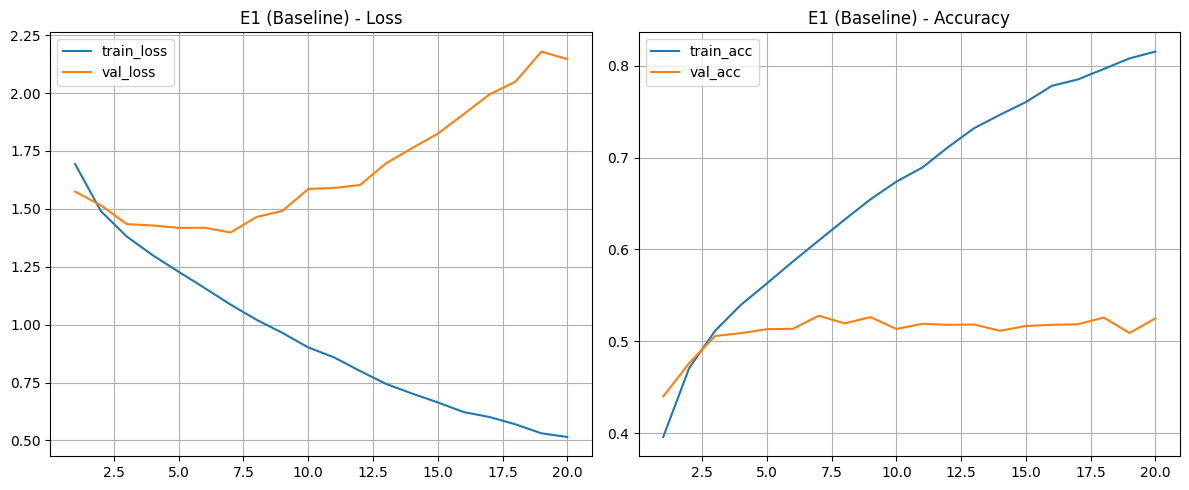

In [18]:
plot_history(
    hist_e1,
    "E1 (Baseline)",
    filename=FIGURES_PATH / "E1_curves.png"
)

На валидационной выборке лучший Accuracy получился ~0.528 - это неплохой результат для бейзлайна. Можно заметить, что после 8 эпохи на валидационной выборке Loss постепенно увеличивается, а Accuracy не растет -  наступает переобучение, а обобщающая способность модели не растет.

### 3.2. E2

In [19]:
# E2: Dropout (p = 0.2)
m_cfg_e2 = {
    "hidden_dims":hidden_dims,
    "dropout_p": 0.2,
    "use_batchnorm": False
}

model_e2, hist_e2, _ = run_experiment(
    "E2",
    m_cfg_e2,
    o_cfg_base,
    epochs=20
)

epoch 01/20 | train loss=1.7985, acc=0.3574 | val loss=1.6191, acc=0.4286
epoch 02/20 | train loss=1.6342, acc=0.4216 | val loss=1.5524, acc=0.4512
epoch 03/20 | train loss=1.5619, acc=0.4482 | val loss=1.4963, acc=0.4847
epoch 04/20 | train loss=1.5209, acc=0.4652 | val loss=1.4958, acc=0.4676
epoch 05/20 | train loss=1.4759, acc=0.4800 | val loss=1.4622, acc=0.4922
epoch 06/20 | train loss=1.4441, acc=0.4882 | val loss=1.4627, acc=0.4885
epoch 07/20 | train loss=1.4123, acc=0.5021 | val loss=1.4282, acc=0.5047
epoch 08/20 | train loss=1.3739, acc=0.5170 | val loss=1.4153, acc=0.5064
epoch 09/20 | train loss=1.3507, acc=0.5230 | val loss=1.4153, acc=0.5054
epoch 10/20 | train loss=1.3223, acc=0.5328 | val loss=1.4059, acc=0.5145
epoch 11/20 | train loss=1.3043, acc=0.5369 | val loss=1.4099, acc=0.5059
epoch 12/20 | train loss=1.2769, acc=0.5484 | val loss=1.4029, acc=0.5109
epoch 13/20 | train loss=1.2548, acc=0.5573 | val loss=1.4119, acc=0.5131
epoch 14/20 | train loss=1.2306, acc=0

Plot saved to: artifacts/figures/E2_curves.png


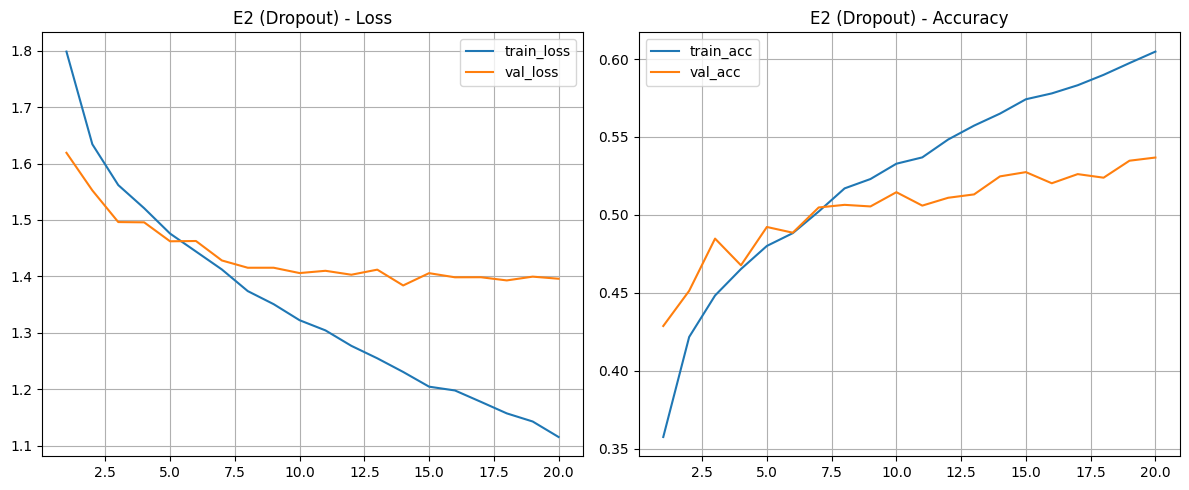

In [20]:
plot_history(
    hist_e2,
    "E2 (Dropout)",
    filename=FIGURES_PATH / "E2_curves.png"
)

Лучшая валидационная точность у модели с Dropout ~0.537 - немного выиграли по сравнению с бейзлайном. Loss и Accuracy не начали заметно падать под конец обучения, но и практически не росли. Таким образом, к 12-14 эпохе мы достигли порога качества. По видимому, переобучения не случилось.

### 3.3. E3

In [21]:
# E3: BatchNorm
m_cfg_e3 = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": True
}

model_e3, hist_e3, _ = run_experiment(
    "E3",
    m_cfg_e3,
    o_cfg_base,
    epochs=20
)

epoch 01/20 | train loss=1.6392, acc=0.4105 | val loss=1.4564, acc=0.4854
epoch 02/20 | train loss=1.4231, acc=0.4901 | val loss=1.3880, acc=0.5010
epoch 03/20 | train loss=1.3108, acc=0.5336 | val loss=1.3234, acc=0.5314
epoch 04/20 | train loss=1.2315, acc=0.5643 | val loss=1.3165, acc=0.5313
epoch 05/20 | train loss=1.1594, acc=0.5885 | val loss=1.3258, acc=0.5422
epoch 06/20 | train loss=1.1021, acc=0.6086 | val loss=1.3163, acc=0.5415
epoch 07/20 | train loss=1.0368, acc=0.6303 | val loss=1.2995, acc=0.5498
epoch 08/20 | train loss=0.9721, acc=0.6538 | val loss=1.3218, acc=0.5493
epoch 09/20 | train loss=0.9094, acc=0.6780 | val loss=1.3459, acc=0.5485
epoch 10/20 | train loss=0.8563, acc=0.6946 | val loss=1.3563, acc=0.5505
epoch 11/20 | train loss=0.7943, acc=0.7166 | val loss=1.3747, acc=0.5478
epoch 12/20 | train loss=0.7735, acc=0.7231 | val loss=1.4500, acc=0.5464
epoch 13/20 | train loss=0.6871, acc=0.7562 | val loss=1.5152, acc=0.5358
epoch 14/20 | train loss=0.6531, acc=0

Plot saved to: artifacts/figures/E3_curves.png


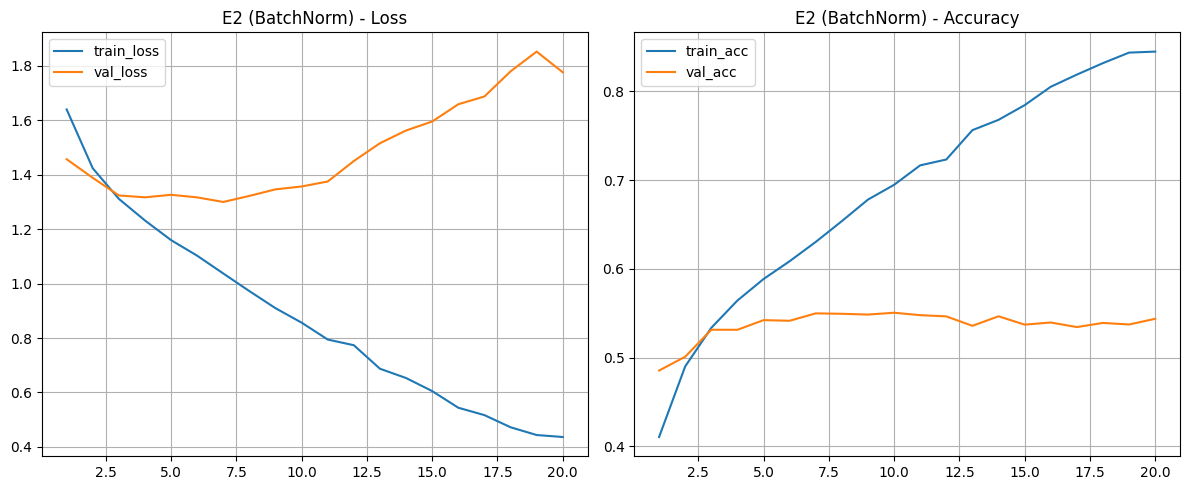

In [22]:
plot_history(
    hist_e3,
    "E2 (BatchNorm)",
    filename=FIGURES_PATH / "E3_curves.png"
)

BatchNorm улучшил качество модели (лучшая точность ~0.551), но не спас от переобучения - после 7 эпохи loss неуклонно растет, а качество не улучшается.

### 3.4. E4

In [23]:
# E4: Dropout (p = 0.2) + BatchNorm + EarlyStopping (patience = 4, min_delta = 5e-4)
m_cfg_e4 = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.2,
    "use_batchnorm": True
}
es = EarlyStopping(patience=4, min_delta=5e-4)

model_e4, hist_e4, config_e4 = run_experiment(
    "E4",
    m_cfg_e4,
    o_cfg_base,
    epochs=50,
    early_stopping=es
)

epoch 01/50 | train loss=1.7134, acc=0.3843 | val loss=1.5086, acc=0.4650
epoch 02/50 | train loss=1.5404, acc=0.4510 | val loss=1.4408, acc=0.4824
epoch 03/50 | train loss=1.4485, acc=0.4841 | val loss=1.3644, acc=0.5190
epoch 04/50 | train loss=1.3910, acc=0.5052 | val loss=1.3457, acc=0.5280
epoch 05/50 | train loss=1.3476, acc=0.5207 | val loss=1.3458, acc=0.5254
epoch 06/50 | train loss=1.2964, acc=0.5377 | val loss=1.3083, acc=0.5342
epoch 07/50 | train loss=1.2638, acc=0.5490 | val loss=1.2833, acc=0.5377
epoch 08/50 | train loss=1.2207, acc=0.5649 | val loss=1.2728, acc=0.5493
epoch 09/50 | train loss=1.1932, acc=0.5733 | val loss=1.2588, acc=0.5573
epoch 10/50 | train loss=1.1626, acc=0.5861 | val loss=1.2529, acc=0.5567
epoch 11/50 | train loss=1.1309, acc=0.5973 | val loss=1.2537, acc=0.5575
epoch 12/50 | train loss=1.1136, acc=0.6024 | val loss=1.2636, acc=0.5552
epoch 13/50 | train loss=1.0764, acc=0.6163 | val loss=1.2472, acc=0.5617
epoch 14/50 | train loss=1.0469, acc=0

Plot saved to: artifacts/figures/curves_best.png


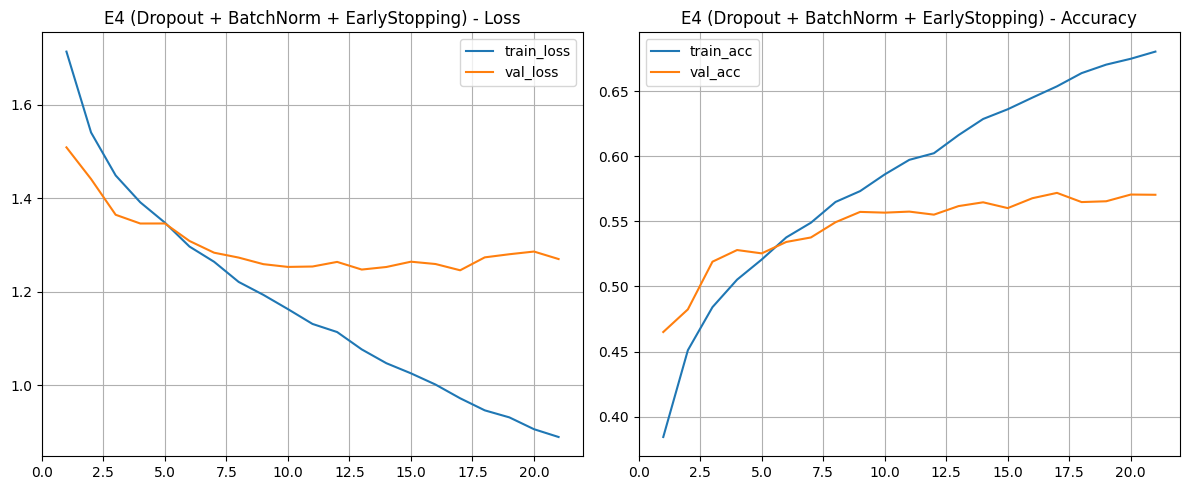

In [24]:
plot_history(
    hist_e4,
    "E4 (Dropout + BatchNorm + EarlyStopping)",
    filename=FIGURES_PATH / "curves_best.png"
)

Комбинация всех техник (Dropout + BatchNorm + Early Stopping) дала закономерный прирост - мы достигли наилучшей точности ~0.572. Early Stopping предотвратил переобучение, остановив обучение на эпохе 21.

Лучшую модель (из E4) необходимо сохранить.

In [25]:
# Сохранение лучшей модели (E4)
torch.save(model_e4.state_dict(), ARTIFACTS_PATH / "best_model.pt")
print("Saved best_model.pt")

Saved best_model.pt


In [26]:
# Сохранение конфигурации лучшей модели (используем возвращенный config_e4)
with open(ARTIFACTS_PATH / "best_config.json", "w") as f:
    json.dump(config_e4, f, indent=2)
print("Saved best_config.json")

Saved best_config.json


## 4. LR, оптимизаторы, weight decay (Часть B)

Мы проведем 3 эксперимента (O1 - O3):
  1. **O1 (большой LR)**: используем Adam и огромный LR, равный 0.1 (1e-1). Обучим 8 эпох и посмотрим, как ведут себя loss и метрики.
  2. **O2 (маленький LR)**: покажем, что обучение двигается чудовищно медленно на 8 эпохах. Оптимизатор Adam, LR равен 0.00001 (1e-5).
  3. **O3 (SGD + momentum + weight decay)**: SGD с momentum = 0.9 и weight_decay = 0.0001 (1e-4). Поставим разумный LR = 0.001 (1e-3), обучим на 8 эпохах.

Функция для экспериментов та же.

In [27]:
# Скрытые слои те же
hidden_dims = (512, 256, 128)

# Поставим "хороший" конфиг для модели, показавший неплохой результат ранее
m_cfg_opt = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.2,
    "use_batchnorm": True
}

### 4.1. O1

In [28]:
# O1: LR слишком большой (1e-1)
o_cfg_o1 = {
    "type": "Adam",
    "lr": 1e-1,
    "weight_decay": 0
}

model_o1, hist_o1, _ = run_experiment(
    "O1",
    m_cfg_opt,
    o_cfg_o1,
    epochs=8
)

epoch 01/8 | train loss=2.0108, acc=0.2556 | val loss=1.8030, acc=0.3373
epoch 02/8 | train loss=1.9102, acc=0.2903 | val loss=1.7908, acc=0.3185
epoch 03/8 | train loss=1.8536, acc=0.3167 | val loss=1.6892, acc=0.3941
epoch 04/8 | train loss=1.8179, acc=0.3344 | val loss=1.7538, acc=0.3764
epoch 05/8 | train loss=1.8255, acc=0.3319 | val loss=1.6752, acc=0.3937
epoch 06/8 | train loss=1.7990, acc=0.3360 | val loss=1.6763, acc=0.3825
epoch 07/8 | train loss=1.7930, acc=0.3450 | val loss=1.7173, acc=0.4021
epoch 08/8 | train loss=1.7648, acc=0.3556 | val loss=1.5987, acc=0.4405
Experiment O1 finished.
Epochs: 8
Best Val Acc: 0.4405


### 4.2. O2

In [29]:
# O2: LR слишком маленький (1e-5)
o_cfg_o2 = {
    "type": "Adam",
    "lr": 1e-5,
    "weight_decay": 0
}

model_o2, hist_o2, _ = run_experiment(
    "O2",
    m_cfg_opt,
    o_cfg_o2,
    epochs=8
)

epoch 01/8 | train loss=2.0791, acc=0.2630 | val loss=1.8935, acc=0.3704
epoch 02/8 | train loss=1.8833, acc=0.3513 | val loss=1.7804, acc=0.4045
epoch 03/8 | train loss=1.7926, acc=0.3871 | val loss=1.7045, acc=0.4293
epoch 04/8 | train loss=1.7299, acc=0.4066 | val loss=1.6424, acc=0.4471
epoch 05/8 | train loss=1.6776, acc=0.4275 | val loss=1.6013, acc=0.4582
epoch 06/8 | train loss=1.6362, acc=0.4377 | val loss=1.5757, acc=0.4652
epoch 07/8 | train loss=1.5973, acc=0.4494 | val loss=1.5448, acc=0.4717
epoch 08/8 | train loss=1.5679, acc=0.4605 | val loss=1.5102, acc=0.4807
Experiment O2 finished.
Epochs: 8
Best Val Acc: 0.4807


Теперь посмотрим на графики для O1 и O2.

Saved curves_lr_extremes.png


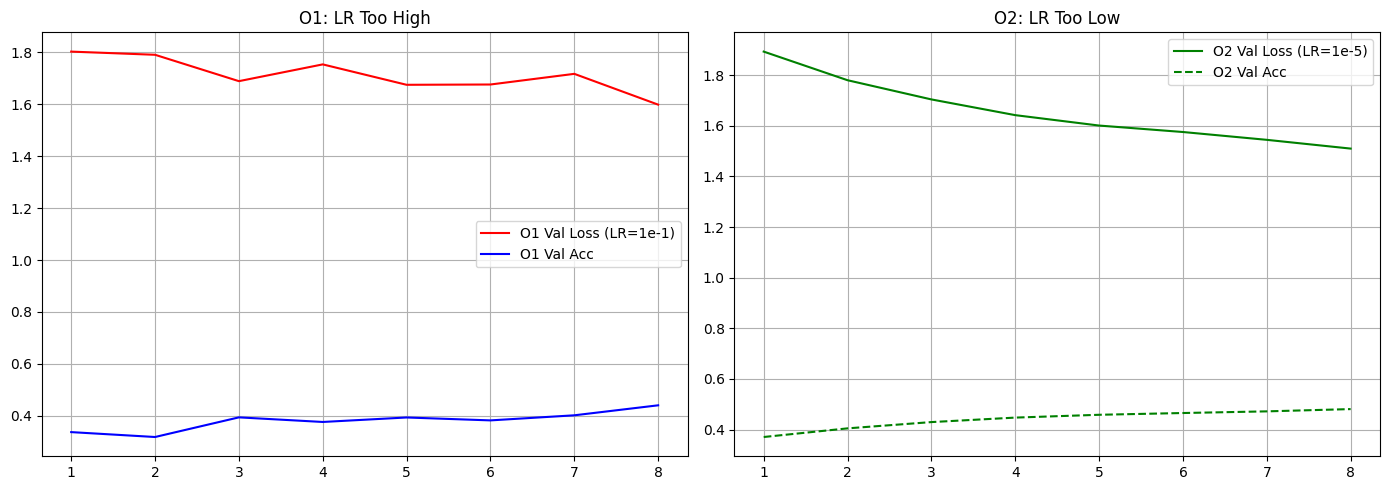

In [30]:
# График сравнения LR (O1 и O2)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# O1 Plot
epochs_o1 = np.arange(1, len(hist_o1["train_loss"]) + 1)
axs[0].plot(epochs_o1, hist_o1["val_loss"], label="O1 Val Loss (LR=1e-1)", color="red")
axs[0].plot(epochs_o1, hist_o1["val_acc"], label="O1 Val Acc", color="blue")
axs[0].set_title("O1: LR Too High")
axs[0].legend()
axs[0].grid(True)

# O2 Plot
epochs_o2 = np.arange(1, len(hist_o2["train_loss"]) + 1)
axs[1].plot(epochs_o2, hist_o2["val_loss"], label="O2 Val Loss (LR=1e-5)", color="green")
axs[1].plot(epochs_o2, hist_o2["val_acc"], label="O2 Val Acc", linestyle="--", color="green")
axs[1].set_title("O2: LR Too Low")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "curves_lr_extremes.png")
print("Saved curves_lr_extremes.png")

plt.show()

In [31]:
# O3: SGD + Momentum + Weight Decay
o_cfg_o3 = {
    "type": "SGD",
    "lr": 1e-2,
    "momentum": 0.9,
    "weight_decay": 1e-4
}

model_o3, hist_o3, _ = run_experiment(
    "O3",
    m_cfg_opt,
    o_cfg_o3,
    epochs=8
)

epoch 01/8 | train loss=1.7260, acc=0.3786 | val loss=1.5132, acc=0.4613
epoch 02/8 | train loss=1.5509, acc=0.4437 | val loss=1.4371, acc=0.4842
epoch 03/8 | train loss=1.4675, acc=0.4760 | val loss=1.3653, acc=0.5128
epoch 04/8 | train loss=1.4135, acc=0.4957 | val loss=1.3587, acc=0.5165
epoch 05/8 | train loss=1.3697, acc=0.5100 | val loss=1.3462, acc=0.5206
epoch 06/8 | train loss=1.3309, acc=0.5244 | val loss=1.3287, acc=0.5246
epoch 07/8 | train loss=1.2907, acc=0.5398 | val loss=1.2903, acc=0.5364
epoch 08/8 | train loss=1.2567, acc=0.5505 | val loss=1.2812, acc=0.5413
Experiment O3 finished.
Epochs: 8
Best Val Acc: 0.5413


Plot saved to: artifacts/figures/O3_curves .png


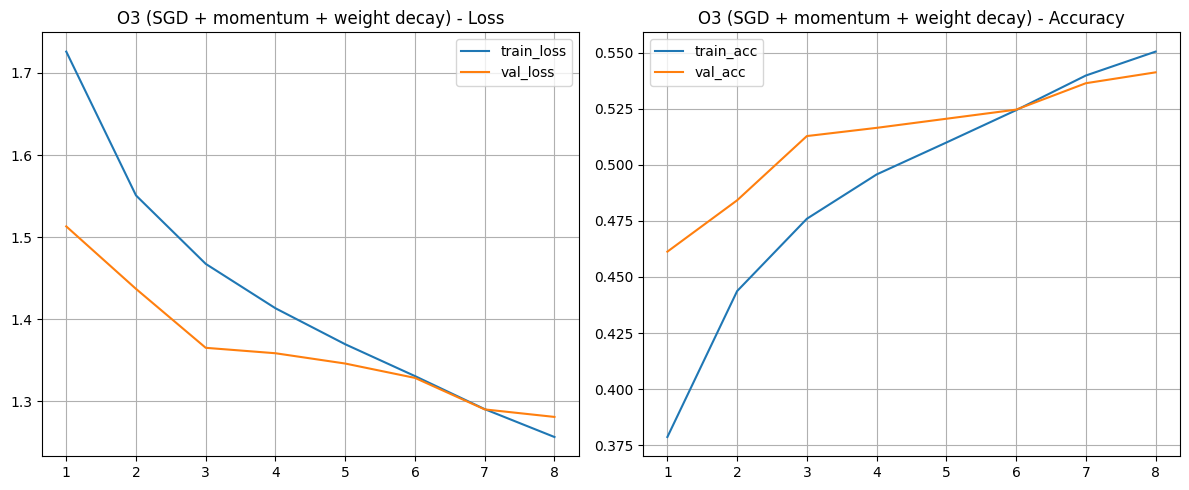

In [32]:
plot_history(
    hist_o3,
    "O3 (SGD + momentum + weight decay)",
    filename=FIGURES_PATH / "O3_curves .png"
)

## 5. Результаты

Результаты по всем экспериментам сохраним в `runs.csv`.

In [33]:
csv_path = ARTIFACTS_PATH / "runs.csv"
if all_runs:
    keys = all_runs[0].keys()
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(all_runs)
    print(f"Saved runs.csv to {csv_path}")
else:
    print("No runs to save")

Saved runs.csv to artifacts/runs.csv


Посмотрим итоговую точность на тестовой выборке у модели из эксперимента E4.

In [34]:
model_e4.eval()
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)

print(f"FINAL TEST EVALUATION (Best Model E4):")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

FINAL TEST EVALUATION (Best Model E4):
Test Loss: 1.2419, Test Accuracy: 0.5676
